# Experimentos de modelagem - Busca Bayesiana (Optuna)

Notebook independente da API para experimentar os modelos candidatos com `dados_tratados/dados_tratados/dados_para_teste.csv`.

Todo o notebook esta focado em **um unico experimento de busca bayesiana de hiperparametros (Optuna)**, aplicado da mesma forma aos modelos candidatos: CatBoost, XGBoost, Random Forest e LightGBM. A avaliacao usa K-Fold no treinamento de cada tentativa, e todos os modelos sao otimizados e comparados no mesmo fluxo.

In [24]:
%pip install -q xgboost lightgbm catboost optuna

from pathlib import Path
from typing import Any, Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import optuna
except ImportError:
    optuna = None

def encontrar_arquivo_dados() -> Path:
    caminho_relativo = Path("dados_tratados") / "dados_tratados" / "imoveis_tratado.csv"
    candidatos = [Path.cwd(), *Path.cwd().parents, Path.home() / "Tiago/git/pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real"]
    for base in candidatos:
        caminho = base / caminho_relativo
        if caminho.exists():
            return caminho
    raise FileNotFoundError(f"Arquivo de dados nao encontrado: {caminho_relativo}")

DADOS_PATH = encontrar_arquivo_dados()

# Pasta para salvar os modelos/artefatos dentro do Colab
ARTIFACTS_DIR = Path("/content/artifacts_modelagem")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 3
N_TRIALS = 50  # numero de tentativas da busca bayesiana, por modelo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\andriel_orbi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Features, alvo e carregamento dos dados

In [25]:
TARGET = "preco"

NUMERIC_FEATURES = [
    "area_m2",
    "quartos",
    "banheiros",
    "suites",
    "andar",
    "vagas",
]

BOOLEAN_FEATURES = [
    "portaria",
    "vista_mar",
    "condominio_fechado",
    "piscina",
    "deck",
    "varanda_gourmet",
    "varanda",
    "academia",
    "salao_festa",
    "salao_jogos",
    "quadra_campo",
]

CATEGORICAL_FEATURES = [
    "bairro",
    "tipo_imovel_padronizado",
]

MODEL_FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES + BOOLEAN_FEATURES

df = pd.read_csv(DADOS_PATH)

faltantes = [coluna for coluna in MODEL_FEATURES + [TARGET] if coluna not in df.columns]
if faltantes:
    raise ValueError(f"Colunas obrigatorias ausentes: {faltantes}")

dados = df[MODEL_FEATURES + [TARGET]].copy()

for coluna in NUMERIC_FEATURES + [TARGET]:
    dados[coluna] = pd.to_numeric(dados[coluna], errors="coerce")

for coluna in BOOLEAN_FEATURES:
    dados[coluna] = dados[coluna].fillna(False).astype(bool)

dados = dados.dropna(subset=MODEL_FEATURES + [TARGET]).reset_index(drop=True)
X = dados[MODEL_FEATURES].copy()
y = dados[TARGET].copy()

print(f"Dataset: {DADOS_PATH}")
print(f"Linhas validas: {len(X)}")
print(f"Colunas: {len(X.columns)} features + alvo")
display(X.head())


Dataset: c:\Users\andriel_orbi\Tiago\git\pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real\dados_tratados\dados_tratados\imoveis_tratado.csv
Linhas validas: 3711
Colunas: 19 features + alvo


,bairro,tipo_imovel_padronizado,area_m2,quartos,banheiros,suites,andar,vagas,portaria,vista_mar,condominio_fechado,piscina,deck,varanda_gourmet,varanda,academia,salao_festa,salao_jogos,quadra_campo
0,Cambeba,apartamento_padrao,54.0,2.0,2.0,1.0,1.0,1.0,True,False,True,True,True,False,False,True,True,False,True
1,Mondubim,casa_padrao,100.0,3.0,3.0,2.0,0.0,2.0,False,False,False,False,True,False,True,False,False,False,False
2,Aracapé,apartamento_padrao,51.0,2.0,2.0,1.0,1.0,1.0,True,False,True,True,False,True,True,False,True,False,True
3,Aldeota,apartamento_padrao,135.0,3.0,4.0,3.0,0.0,3.0,False,False,False,True,False,False,False,True,True,True,True
4,Mondubim,apartamento_padrao,63.0,3.0,2.0,1.0,2.0,2.0,False,False,False,True,False,False,True,False,False,False,False


## 3. PrÃƒÂ©-processamento e mÃƒÂ©tricas

In [26]:
def one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def criar_preprocessador() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", one_hot_encoder()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
            ("boolean", "passthrough", BOOLEAN_FEATURES),
        ],
        remainder="drop",
    )


def rmse(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def calcular_metricas(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "rmse": rmse(y_true, y_pred),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)),
    }


def criar_pipeline(estimator: Any) -> Pipeline:
    return Pipeline(
        steps=[
            ("preprocessor", criar_preprocessador()),
            ("regressor", estimator),
        ]
    )


## 4. Modelos candidatos e espacos de busca bayesiana

Cada modelo tem um `builder` (constroi o estimador a partir de um dict de hiperparametros) e uma funcao `suggest` (define, via Optuna, o espaco de busca bayesiana daquele modelo). O experimento usa apenas CatBoost, XGBoost, Random Forest e LightGBM, todos avaliados com K-Fold.

In [27]:
def require_xgboost():
    try:
        from xgboost import XGBRegressor
    except ImportError as exc:
        raise ImportError("Instale xgboost para rodar este experimento.") from exc
    return XGBRegressor


def require_lightgbm():
    try:
        from lightgbm import LGBMRegressor
    except ImportError as exc:
        raise ImportError("Instale lightgbm para rodar este experimento.") from exc
    return LGBMRegressor


def require_catboost():
    try:
        from catboost import CatBoostRegressor
    except ImportError as exc:
        raise ImportError("Instale catboost para rodar este experimento.") from exc
    return CatBoostRegressor


def build_xgboost(params: dict[str, Any]):
    XGBRegressor = require_xgboost()
    return XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        **params,
    )


def build_lightgbm(params: dict[str, Any]):
    LGBMRegressor = require_lightgbm()
    return LGBMRegressor(
        objective="regression",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        **params,
    )


def build_catboost(params: dict[str, Any]):
    CatBoostRegressor = require_catboost()
    return CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        **params,
    )


def build_random_forest(params: dict[str, Any]):
    return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)


def suggest_random_forest(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 900, step=100),
        "max_depth": trial.suggest_int("max_depth", 4, 32),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
    }


def suggest_xgboost(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }


def suggest_lightgbm(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "max_depth": trial.suggest_int("max_depth", 3, 14),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }


def suggest_catboost(trial):
    return {
        "iterations": trial.suggest_int("iterations", 300, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 2.0),
    }


# Apenas os modelos abaixo seguem a mesma estrategia: busca bayesiana (Optuna) + K-Fold
MODEL_SPECS = {
    "catboost": {"nome": "CatBoost", "builder": build_catboost, "suggest": suggest_catboost},
    "xgboost": {"nome": "XGBoost", "builder": build_xgboost, "suggest": suggest_xgboost},
    "random_forest": {"nome": "Random Forest", "builder": build_random_forest, "suggest": suggest_random_forest},
    "lightgbm": {"nome": "LightGBM", "builder": build_lightgbm, "suggest": suggest_lightgbm},
}

list(MODEL_SPECS)


['catboost', 'xgboost', 'random_forest', 'lightgbm']

## 5. Rotina ÃƒÂºnica de busca bayesiana

Uma sÃƒÂ³ rotina (`buscar_com_optuna`) ÃƒÂ© usada para **todos** os modelos: cada trial do Optuna sugere hiperparÃƒÂ¢metros, valida com K-Fold e a mÃƒÂ©trica otimizada ÃƒÂ© o RMSE mÃƒÂ©dio. `treinar_modelo` encapsula a busca + ajuste final + persistÃƒÂªncia do modelo, e ÃƒÂ© chamada em loop para todos os candidatos na cÃƒÂ©lula seguinte (sem uma cÃƒÂ©lula por modelo).

In [28]:
def cross_validate_params(builder: Callable[[dict[str, Any]], Any], params: dict[str, Any]) -> dict[str, float]:
    cv = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for train_idx, valid_idx in cv.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
        pipeline = criar_pipeline(builder(params))
        pipeline.fit(X_train, y_train)
        pred = pipeline.predict(X_valid)
        fold_metrics.append(calcular_metricas(y_valid, pred))

    return {
        "rmse": float(np.mean([m["rmse"] for m in fold_metrics])),
        "mae": float(np.mean([m["mae"] for m in fold_metrics])),
        "r2": float(np.mean([m["r2"] for m in fold_metrics])),
    }


def montar_historico_convergencia(study: Any, model_key: str, modelo: str) -> pd.DataFrame:
    linhas = []
    melhor_rmse = np.inf
    for trial in study.trials:
        if trial.value is None:
            continue
        melhor_rmse = min(melhor_rmse, float(trial.value))
        linhas.append(
            {
                "model_key": model_key,
                "modelo": modelo,
                "trial": trial.number,
                "rmse": float(trial.value),
                "best_rmse_so_far": float(melhor_rmse),
                "mae": trial.user_attrs.get("mae"),
                "r2": trial.user_attrs.get("r2"),
            }
        )
    return pd.DataFrame(linhas)


def buscar_com_optuna(model_key: str, spec: dict[str, Any]) -> tuple[dict[str, Any], dict[str, float], pd.DataFrame]:
    if optuna is None:
        raise ImportError("Instale optuna para usar a busca bayesiana.")

    def objective(trial):
        params = spec["suggest"](trial)
        metrics = cross_validate_params(spec["builder"], params)
        trial.set_user_attr("mae", metrics["mae"])
        trial.set_user_attr("r2", metrics["r2"])
        return metrics["rmse"]

    study = optuna.create_study(direction="minimize", study_name=f"{model_key}_rmse")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    historico = montar_historico_convergencia(study, model_key, spec["nome"])
    best_params = dict(study.best_params)
    best_metrics = cross_validate_params(spec["builder"], best_params)
    return best_params, best_metrics, historico


def ajustar_modelo_final(builder: Callable[[dict[str, Any]], Any], params: dict[str, Any]) -> Pipeline:
    pipeline = criar_pipeline(builder(params))
    pipeline.fit(X, y)
    return pipeline


rankings: dict[str, pd.DataFrame] = {}
historicos_convergencia: dict[str, pd.DataFrame] = {}


def treinar_modelo(model_key: str) -> pd.DataFrame:
    if model_key not in MODEL_SPECS:
        raise KeyError(f"Modelo desconhecido: {model_key}")

    spec = MODEL_SPECS[model_key]
    print(f"\n=== Busca bayesiana: {spec['nome']} ===")

    try:
        best_params, best_metrics, historico = buscar_com_optuna(model_key, spec)
    except ImportError as exc:
        print(f"Pulando {spec['nome']}: {exc}")
        return pd.DataFrame()

    estimator = ajustar_modelo_final(spec["builder"], best_params)
    model_dir = ARTIFACTS_DIR / model_key
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(estimator, model_dir / f"{model_key}.pkl")

    ranking = pd.DataFrame(
        [
            {
                "model_key": model_key,
                "modelo": spec["nome"],
                "rmse": best_metrics["rmse"],
                "mae": best_metrics["mae"],
                "r2": best_metrics["r2"],
                "best_params": best_params,
            }
        ]
    )
    ranking.to_csv(model_dir / "ranking.csv", index=False)
    historico.to_csv(model_dir / "convergencia.csv", index=False)
    rankings[model_key] = ranking
    historicos_convergencia[model_key] = historico

    print(
        f"{spec['nome']}: RMSE={best_metrics['rmse']:.2f} | "
        f"MAE={best_metrics['mae']:.2f} | R2={best_metrics['r2']:.4f}"
    )
    return ranking


def convergencia_geral() -> pd.DataFrame:
    if not historicos_convergencia:
        return pd.DataFrame()
    return pd.concat(historicos_convergencia.values(), ignore_index=True)


def ranking_geral() -> pd.DataFrame:
    if not rankings:
        return pd.DataFrame()
    return pd.concat(rankings.values(), ignore_index=True).sort_values("rmse", ignore_index=True)


In [29]:
# Roda a busca bayesiana com K-Fold para os modelos candidatos definidos em MODEL_SPECS
for model_key in MODEL_SPECS:
    treinar_modelo(model_key)

ranking_final = ranking_geral()
display(ranking_final)

if not ranking_final.empty:
    caminho_ranking_final = ARTIFACTS_DIR / "ranking_geral.csv"
    ranking_final.to_csv(caminho_ranking_final, index=False)
    print(f"Ranking consolidado salvo em: {caminho_ranking_final}")

convergencia_final = convergencia_geral()
if not convergencia_final.empty:
    caminho_convergencia_final = ARTIFACTS_DIR / "convergencia_geral.csv"
    convergencia_final.to_csv(caminho_convergencia_final, index=False)
    print(f"Historico de convergencia salvo em: {caminho_convergencia_final}")


[I 2026-06-27 17:15:00,322] A new study created in memory with name: catboost_rmse



=== Busca bayesiana: CatBoost ===


[I 2026-06-27 17:15:08,845] Trial 0 finished with value: 431380.69293967664 and parameters: {'iterations': 807, 'learning_rate': 0.053018071697744355, 'depth': 8, 'l2_leaf_reg': 4.929080965715193, 'bagging_temperature': 0.5529979146054956, 'random_strength': 0.15149667588979931}. Best is trial 0 with value: 431380.69293967664.
[I 2026-06-27 17:16:56,701] Trial 1 finished with value: 435955.4546484486 and parameters: {'iterations': 1029, 'learning_rate': 0.08336657682525744, 'depth': 10, 'l2_leaf_reg': 5.294919053347819, 'bagging_temperature': 0.3708383015370157, 'random_strength': 1.1467757090814734}. Best is trial 0 with value: 431380.69293967664.
[I 2026-06-27 17:17:34,180] Trial 2 finished with value: 453613.10756925616 and parameters: {'iterations': 353, 'learning_rate': 0.1991305784993102, 'depth': 10, 'l2_leaf_reg': 1.737890707927552, 'bagging_temperature': 0.09799708740823487, 'random_strength': 0.04899866266881725}. Best is trial 0 with value: 431380.69293967664.
[I 2026-06-27 

CatBoost: RMSE=422171.53 | MAE=234471.00 | R2=0.7133

=== Busca bayesiana: XGBoost ===


[I 2026-06-27 17:27:40,763] Trial 0 finished with value: 417014.92248086847 and parameters: {'n_estimators': 852, 'learning_rate': 0.01773001240070717, 'max_depth': 7, 'min_child_weight': 5.111208343531631, 'subsample': 0.7370094732360815, 'colsample_bytree': 0.6656262651888696, 'reg_alpha': 0.02508111812197669, 'reg_lambda': 0.007465816397075173}. Best is trial 0 with value: 417014.92248086847.
[I 2026-06-27 17:27:43,322] Trial 1 finished with value: 455309.3778315934 and parameters: {'n_estimators': 791, 'learning_rate': 0.13476472145898719, 'max_depth': 6, 'min_child_weight': 2.0626257749696446, 'subsample': 0.713728117727866, 'colsample_bytree': 0.8540985880138696, 'reg_alpha': 0.00033326269855777886, 'reg_lambda': 0.33091185249768335}. Best is trial 0 with value: 417014.92248086847.
[I 2026-06-27 17:27:45,558] Trial 2 finished with value: 425880.4922477491 and parameters: {'n_estimators': 719, 'learning_rate': 0.027302722360313572, 'max_depth': 6, 'min_child_weight': 8.46553513678

...

Random Forest: RMSE=431852.03 | MAE=236597.69 | R2=0.6999

=== Busca bayesiana: LightGBM ===


C:\Users\andriel_orbi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\andriel_orbi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\andriel_orbi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
[I 2026-06-27 17:33:49,463] Trial 0 finished with value: 461880.9838615255 and parameters: {'n_estimators': 885, 'l

LightGBM: RMSE=414976.29 | MAE=234524.12 | R2=0.7227


,model_key,modelo,rmse,mae,r2,best_params
0,xgboost,XGBoost,414288.795907,232003.720238,0.723647,"{'n_estimators': 1057, 'learning_rate': 0.0107..."
1,lightgbm,LightGBM,414976.293208,234524.124198,0.722729,"{'n_estimators': 312, 'learning_rate': 0.02610..."
2,catboost,CatBoost,422171.533600,234471.000218,0.713300,"{'iterations': 1221, 'learning_rate': 0.053784..."
3,random_forest,Random Forest,431852.026204,236597.693192,0.699882,"{'n_estimators': 700, 'max_depth': 19, 'min_sa..."


Ranking consolidado salvo em: \content\artifacts_modelagem\ranking_geral.csv
Historico de convergencia salvo em: \content\artifacts_modelagem\convergencia_geral.csv


## 6. Convergencia da busca bayesiana

As curvas abaixo mostram o melhor RMSE encontrado ate cada tentativa. Quando a linha fica quase plana, a busca provavelmente ja esta perto do limite de melhora dentro do espaco de hiperparametros definido.

,model_key,modelo,trial,rmse,best_rmse_so_far,mae,r2
0,catboost,CatBoost,0,431380.692940,431380.69294,232782.684578,0.700581
1,catboost,CatBoost,1,435955.454648,431380.69294,233889.002904,0.694128
2,catboost,CatBoost,2,453613.107569,431380.69294,239676.517672,0.668836
3,catboost,CatBoost,3,431790.630136,431380.69294,236885.332374,0.699909
4,catboost,CatBoost,4,426841.385310,426841.38531,230143.288000,0.706952


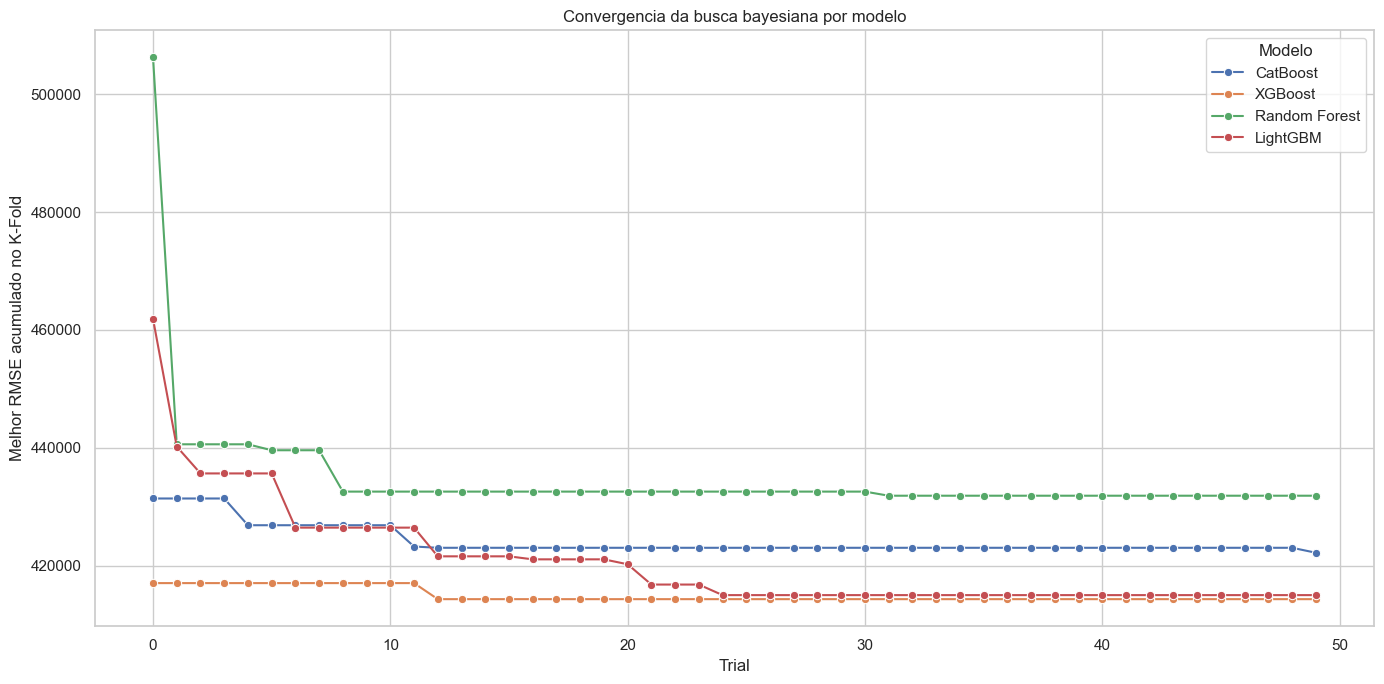

In [30]:
if 'convergencia_final' not in globals() or convergencia_final.empty:
    caminho_convergencia_final = ARTIFACTS_DIR / 'convergencia_geral.csv'
    convergencia_final = pd.read_csv(caminho_convergencia_final) if caminho_convergencia_final.exists() else pd.DataFrame()

if convergencia_final.empty:
    print('Nenhum historico de convergencia disponivel. Rode a celula de treinamento primeiro.')
else:
    display(convergencia_final.head())
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=convergencia_final, x='trial', y='best_rmse_so_far', hue='modelo', marker='o')
    plt.title('Convergencia da busca bayesiana por modelo')
    plt.xlabel('Trial')
    plt.ylabel('Melhor RMSE acumulado no K-Fold')
    plt.legend(title='Modelo')
    plt.tight_layout()
    plt.show()


## 7. Comparacao de desempenho dos modelos

Tabela e graficos comparativos com base no `ranking_final` produzido pela busca bayesiana com K-Fold.
- O **RMSE** mede o erro (quanto menor, melhor).
- O **R2** mede o poder de explicacao do modelo (quanto mais proximo de 1, melhor).

Tabela de Desempenho dos Modelos:


,modelo,rmse,mae,r2
0,XGBoost,414288.795907,232003.720238,0.723647
1,LightGBM,414976.293208,234524.124198,0.722729
2,CatBoost,422171.533600,234471.000218,0.713300
3,Random Forest,431852.026204,236597.693192,0.699882


C:\Users\andriel_orbi\AppData\Local\Temp\ipykernel_31536\4074103839.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_final.sort_values("rmse"), x="rmse", y="modelo", ax=axes[0], palette="viridis")
C:\Users\andriel_orbi\AppData\Local\Temp\ipykernel_31536\4074103839.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_final.sort_values("r2", ascending=False), x="r2", y="modelo", ax=axes[1], palette="magma")


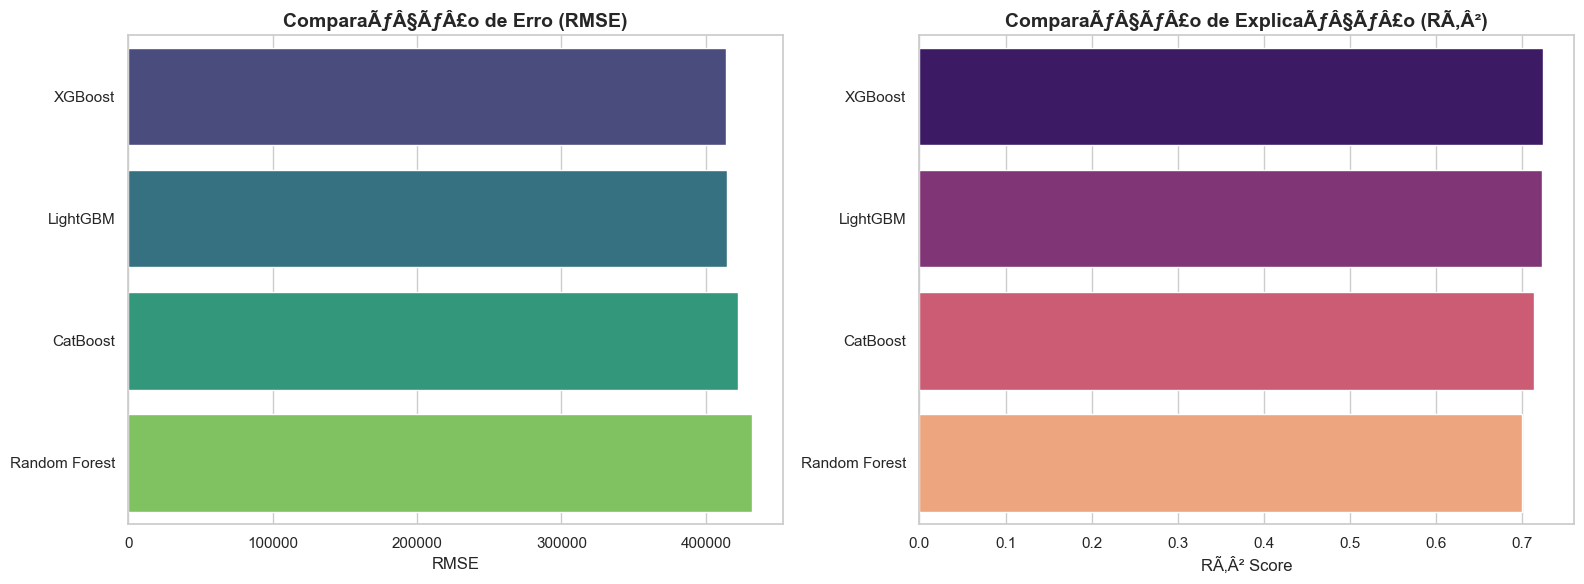

In [31]:
print("Tabela de Desempenho dos Modelos:")
display(ranking_final[["modelo", "rmse", "mae", "r2"]].sort_values(by="rmse").reset_index(drop=True))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=ranking_final.sort_values("rmse"), x="rmse", y="modelo", ax=axes[0], palette="viridis")
axes[0].set_title("ComparaÃƒÂ§ÃƒÂ£o de Erro (RMSE)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=ranking_final.sort_values("r2", ascending=False), x="r2", y="modelo", ax=axes[1], palette="magma")
axes[1].set_title("ComparaÃƒÂ§ÃƒÂ£o de ExplicaÃƒÂ§ÃƒÂ£o (RÃ‚Â²)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("RÃ‚Â² Score")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## 8. Diagnostico do melhor modelo: analise de residuos

AnÃƒÂ¡lise de resÃƒÂ­duos no melhor modelo (menor RMSE na busca bayesiana) para diagnosticar underfitting, overfitting ou heterocedasticidade.

Melhor modelo: XGBOOST


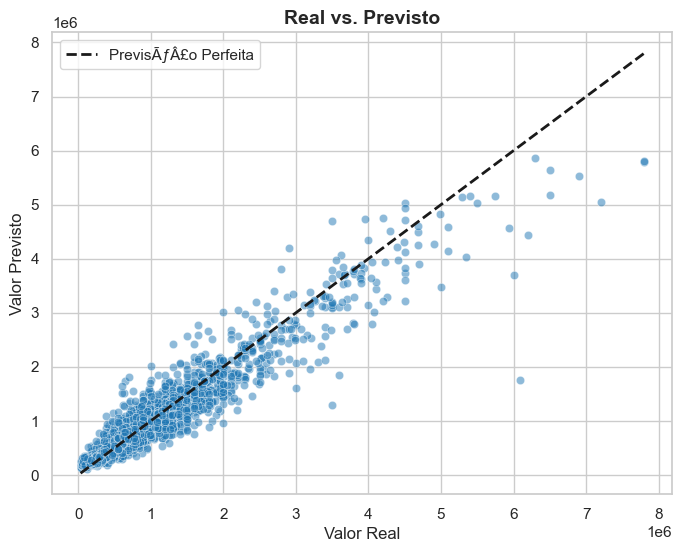

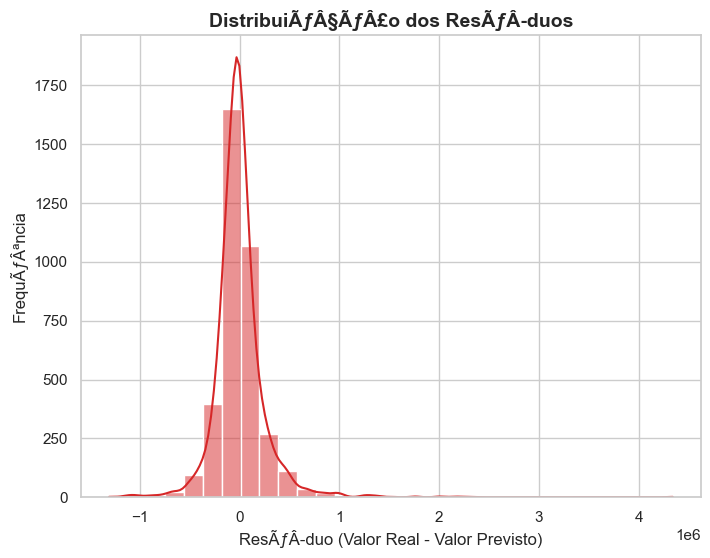

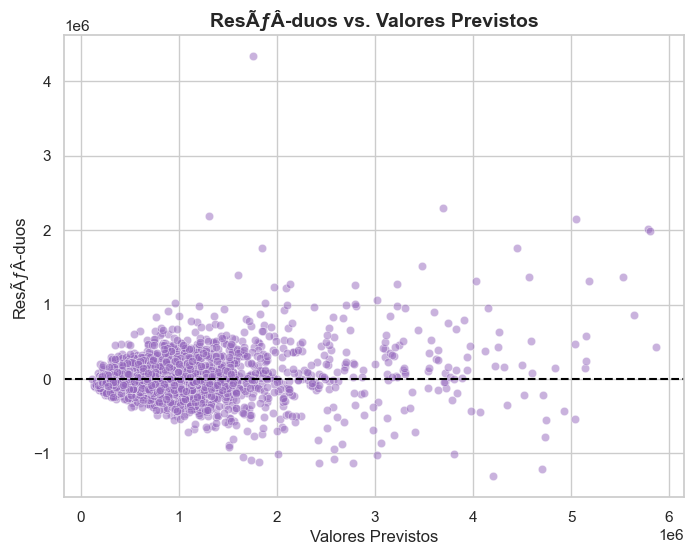

In [32]:
melhor_model_key = ranking_final.sort_values("rmse").iloc[0]["model_key"]
print(f"Melhor modelo: {melhor_model_key.upper()}")

caminho_modelo = ARTIFACTS_DIR / melhor_model_key / f"{melhor_model_key}.pkl"
melhor_modelo = joblib.load(caminho_modelo)

y_pred = melhor_modelo.predict(X)
residuos = y - y_pred

# Valores Reais vs. Previstos
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.5, color="#1f77b4")
min_val, max_val = y.min(), y.max()
plt.plot([min_val, max_val], [min_val, max_val], "k--", lw=2, label="PrevisÃƒÂ£o Perfeita")
plt.title("Real vs. Previsto", fontsize=14, fontweight="bold")
plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.legend()
plt.show()

# Histograma dos ResÃƒÂ­duos (Erros)
plt.figure(figsize=(8, 6))
sns.histplot(residuos, kde=True, color="#d62728", bins=30)
plt.title("DistribuiÃƒÂ§ÃƒÂ£o dos ResÃƒÂ­duos", fontsize=14, fontweight="bold")
plt.xlabel("ResÃƒÂ­duo (Valor Real - Valor Previsto)")
plt.ylabel("FrequÃƒÂªncia")
plt.show()

# ResÃƒÂ­duos vs. Valores Ajustados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuos, alpha=0.5, color="#9467bd")
plt.axhline(0, color="black", linestyle="--")
plt.title("ResÃƒÂ­duos vs. Valores Previstos", fontsize=14, fontweight="bold")
plt.xlabel("Valores Previstos")
plt.ylabel("ResÃƒÂ­duos")
plt.show()
